# Custom Datasets

## Import packages

In [28]:
import torch
import torch.nn as nn
import torch.optim as opt

In [29]:
from torch.utils.data import DataLoader, Dataset # for any data: tuen this into a torch.utils.data.DataLoader = iterable
from torchvision import datasets, transforms # specially for images so for other type go to the proper library

In [30]:
import torchvision
import torchinfo as ti

In [31]:
from typing import Tuple, Dict, List

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.model_selection import train_test_split

In [33]:
import requests

In [34]:
from pathlib import Path
import os
import zipfile

In [35]:
import random

In [36]:
import PIL

In [37]:
import numpy as np

In [38]:
print(torch.__version__)

2.12.0


## Device agnostic code

In [ ]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"The device is: {device} and is {'available' if torch.backends.mps.is_built() else 'not available'}.")

## Get the data

In [ ]:
!wget "https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip"

In [39]:
data_path = Path("data")
image_path = data_path / "pizza_steak_suchi"

In [40]:
if image_path.exists():
    print("folder already exists")
else:
    print("Creating folder....")
    image_path.mkdir()

folder already exists


In [ ]:
# extract the zip file and put it in the correct directory
try:
    with zipfile.ZipFile("pizza_steak_sushi.zip", "r") as zip_file:
        zip_file.extractall(image_path) # path to where we want to extract data to
        print("File extracted ....")
except Exception as e:
    print("No zip file")
    print(e)
else:
    print("Removing zip file....")
    os.remove("pizza_steak_sushi.zip")

## Visualizing the data

In [41]:
def walk_through_dire(dirpath):
    for dirpath, dirnames, filenames in os.walk(dirpath):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}.")

In [42]:
walk_through_dire(image_path)

There are 2 directories and 0 images in data/pizza_steak_suchi.
There are 3 directories and 0 images in data/pizza_steak_suchi/test.
There are 0 directories and 19 images in data/pizza_steak_suchi/test/steak.
There are 0 directories and 31 images in data/pizza_steak_suchi/test/sushi.
There are 0 directories and 25 images in data/pizza_steak_suchi/test/pizza.
There are 3 directories and 0 images in data/pizza_steak_suchi/train.
There are 0 directories and 75 images in data/pizza_steak_suchi/train/steak.
There are 0 directories and 72 images in data/pizza_steak_suchi/train/sushi.
There are 0 directories and 78 images in data/pizza_steak_suchi/train/pizza.


Using `PyTorch` or even `TensorFlow` the proper format of the folders is:

```text
train
    |__
        class_name
                |__ img1
                |__ img2
test
    |__
        class_name
                |__ img1
                |__ img2                

````

this is the way to do it (even with our own datasets for classification **WE SHOULD PUT THE DATA IN THIS FORMAT**)

In [43]:
# setting train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

In [44]:
SEED = 42

In [45]:
# visualizing our data
random.seed(SEED)

In [46]:
image_path_list = list(image_path.glob("*/*/*.jpg")) # * anything at this level starting at the image_path
image_path_list[:2]

[PosixPath('data/pizza_steak_suchi/test/steak/296375.jpg'),
 PosixPath('data/pizza_steak_suchi/test/steak/673127.jpg')]

In [47]:
random_image_path = random.choice(image_path_list)

In [48]:
image_class = random_image_path.parent.stem

In [49]:
with PIL.Image.open(random_image_path.as_posix()) as img:
    print(f"Random image path: {random_image_path.as_posix()}")
    print(f"Image class:{image_class.upper()}")
    print(f"Image height:{img.height}")
    print(f"Image width: {img.width}") # metadata from PIL

Random image path: data/pizza_steak_suchi/test/pizza/2236338.jpg
Image class:PIZZA
Image height:512
Image width: 512


Careful that the shape here is `(HxZxC)` so color channel last whereas PyTorch is color channel first !!! so we need to deal with that later on

## Turn the data into tensors

The principle for ervery datasets to be loaded efficiently:
1. Turn the data into a `torch.utils.data.Dataset`
2. Turn the torch dataset into an iterable: `torch.utils.data.DataLoader`

In [53]:
# First we need to define the kind of transform we want to do: here tensors yes but also resizing and randomflipping
dataset_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

ok so here we see that the transfom has also adapted the shape (especially the color channel) to fit PyTorc

In [55]:
def plot_transformed_images(img_paths, transform, n = 3, seed = None):
    if seed:
        random.seed(seed)
    random_image_paths = random.sample(img_paths, k = n)
    for image_path in random_image_paths:
        with PIL.Image.open(image_path) as file_:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(file_)
            ax[0].set_title(f"Originial \n size:{file_.size}")
            ax[0].axis(False)

            transformed_image = transform(file_).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \n size:{transformed_image.shape}")
            ax[1].axis(False)

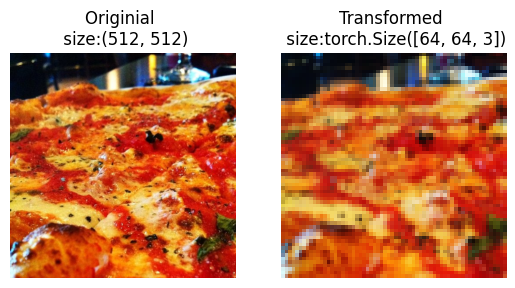

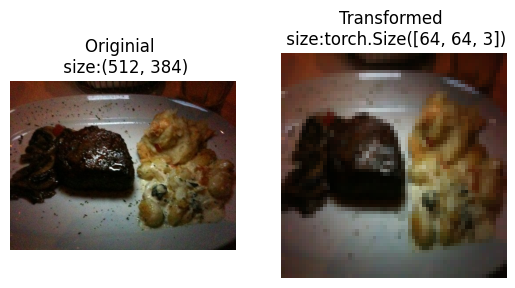

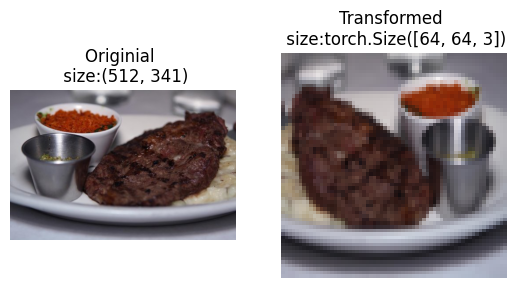

In [56]:
plot_transformed_images(image_path_list, dataset_transform, n = 3, seed = 42)

## Option 1: Loading the data using the `ImageFolder` class 

this assume that we have the classcial classification folder structure. 

So the first step is to create a `torch.utils.data.Datasets` then use the dataloader

In [57]:
train_data = datasets.ImageFolder(root=train_dir, transform=dataset_transform, target_transform=None)
test_data = datasets.ImageFolder(root=test_dir, transform=dataset_transform)

In [58]:
img, label = train_data[0][0], train_data[0][1]

In [59]:
os.cpu_count()

10

In [60]:
train_dataloader = DataLoader(dataset=train_data, 
                              batch_size=32, 
                              #num_workers=5,
                              shuffle=True, # good practice to avoid any patterns with data
                              )
test_dataloader = DataLoader(dataset=test_data, 
                              batch_size=32, 
                              #num_workers=5,
                              shuffle=False, # good practice to avoid any patterns with data
                              )

In [61]:
len(train_dataloader)

8

In [62]:
# check one batch
#next(iter(train_dataloader))

## Option 2: Custom Dataset

this is when we want to load files when our data is not in the proper format to load it with existing dataset function

In [63]:
train_data.classes # this is automatically accessible from the dataset

['pizza', 'steak', 'sushi']

In [64]:
target_directory = train_dir

In [65]:
class_names_found = sorted([entry.name for entry in os.scandir(target_directory)])
class_names_found

['pizza', 'steak', 'sushi']

In [66]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    classes = sorted([entry.name for entry in list(os.scandir(directory)) if entry.is_dir()])
    if not classes:
        raise FileNotFoundError(f"Could not find any classes in {directory}")
    
    class_to_idx = {class_name: i for i, class_name in enumerate(classes)}

    return classes, class_to_idx

In [67]:
find_classes(train_dir) # replicate the functionality of ImageFolder

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [68]:
img, label = train_data[0]
img, label # this what is being returned by the __getitem__ method in the class

(tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
          [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
          [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
          ...,
          [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
          [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
          [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],
 
         [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
          [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
          [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
          ...,
          [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
          [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
          [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],
 
         [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
          [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
          [0.0196, 0.0157, 0.0157,  ...,

In [69]:
# Create a custom dataset to replicate ImageFolder 
class ImageFolderCustom(Dataset):
    def __init__(self, targ_dir: str, transform=None):
        super().__init__()
        self.paths = list(Path(targ_dir).glob("*/*.jpg"))
        self.transform = transform
        self.classes, self.class_to_idx = find_classes(targ_dir)


    def load_image(self, index:int) -> PIL.Image:
        image_path = self.paths[index]
        return PIL.Image.open(image_path)
    

    def __len__(self) -> int:
        return len(self.paths)
    

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        img = self.load_image(index)
        class_name = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_name]

        if self.transform:
            return self.transform(img), class_idx
        else:
            return img, class_idx


In [70]:
# Augment train data
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

# Don't augment test data, only reshape
test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [71]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir, 
                                      transform=train_transforms)
test_data_custom = ImageFolderCustom(targ_dir=test_dir, 
                                     transform=test_transforms)
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x125731550>,
 <__main__.ImageFolderCustom at 0x1263f07d0>)

In [72]:
train_dataloader_custom = DataLoader(dataset=train_data_custom, # use custom created train Dataset
                                     batch_size=1, # how many samples per batch?
                                     num_workers=0, # how many subprocesses to use for data loading? (higher = more)
                                     shuffle=True) # shuffle the data?

test_dataloader_custom = DataLoader(dataset=test_data_custom, # use custom created test Dataset
                                    batch_size=1, 
                                    num_workers=0, 
                                    shuffle=False) # don't usually need to shuffle testing data

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x1263f0910>,
 <torch.utils.data.dataloader.DataLoader at 0x120b68510>)

In [73]:
next(iter(train_dataloader_custom))

[tensor([[[[0.6510, 0.6431, 0.5725,  ..., 0.1843, 0.1529, 0.1373],
           [0.5765, 0.6235, 0.6118,  ..., 0.2471, 0.2235, 0.1922],
           [0.5490, 0.6196, 0.6392,  ..., 0.2980, 0.2824, 0.2353],
           ...,
           [0.3686, 0.3804, 0.3922,  ..., 0.3843, 0.4039, 0.4627],
           [0.3922, 0.3765, 0.3686,  ..., 0.5294, 0.6863, 0.7255],
           [0.3765, 0.3686, 0.3529,  ..., 0.8000, 0.6196, 0.3608]],
 
          [[0.7020, 0.7333, 0.6549,  ..., 0.2196, 0.2078, 0.1843],
           [0.5608, 0.6392, 0.6627,  ..., 0.1961, 0.2196, 0.2235],
           [0.5843, 0.6392, 0.6392,  ..., 0.2000, 0.1882, 0.1725],
           ...,
           [0.1647, 0.1882, 0.2235,  ..., 0.5176, 0.5373, 0.6118],
           [0.1843, 0.1686, 0.1647,  ..., 0.6627, 0.8157, 0.8824],
           [0.1451, 0.1373, 0.1333,  ..., 0.9059, 0.7569, 0.4902]],
 
          [[0.6824, 0.7529, 0.6039,  ..., 0.2902, 0.2745, 0.2510],
           [0.4941, 0.5569, 0.6353,  ..., 0.2314, 0.2784, 0.2902],
           [0.5725, 0.56

## Data Augmentation: Using the Trivial Augment transformation

In [74]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31), # how intense 
    transforms.ToTensor() # use ToTensor() last to get everything between 0 & 1
])

# Don't need to perform augmentation on the test data
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor()
])

## Building a baseline model

Replicate the TinyVGG from the CNN explainer website

In [75]:
simple_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [76]:
train_data_simple = datasets.ImageFolder(root=train_dir, transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir, transform=simple_transform)

In [77]:
device = "cpu"

In [78]:
train_dataloader_simple = DataLoader(batch_size=32, 
                                     num_workers=os.cpu_count()-4, 
                                     dataset=train_data_simple, 
                                     shuffle=True, 
                                     persistent_workers=True, 
                                     prefetch_factor=2)
test_dataloader_simple = DataLoader(dataset=test_data_simple, 
                                    batch_size=32, 
                                    num_workers=os.cpu_count()-4, 
                                    shuffle=False, 
                                    persistent_workers=True, 
                                    prefetch_factor=2)

In [105]:
len(train_dataloader_simple), len(test_dataloader_simple)

(8, 3)

In [79]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        # Feature extractor layuers 
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # classifier layer

        self.classifier_layer = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(out_features=output_shape)
        )

    def forward(self, inputs:torch.Tensor) -> torch.Tensor:
        x = self.block1(inputs)
        x = self.block2(x)
        x = self.classifier_layer(x)
        return x
        # to speed up the process return self.classifier_layer(self.block2(self.block1(inputs)))

In [80]:
img_dummy, label_dummy = next(iter(train_dataloader_simple))
img_dummy.shape, label_dummy.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [81]:
dummy_data = torch.randn(size=(1,3,64,64))

In [82]:
model1 = TinyVGG(input_shape=3, hidden_units=10, output_shape=3).to(device)
dummy_output = model1(img_dummy)
dummy_output.shape, dummy_output.ndim

(torch.Size([32, 3]), 2)

In [83]:
dummy_output[:5]

tensor([[0.0325, 0.0135, 0.0043],
        [0.0316, 0.0064, 0.0052],
        [0.0341, 0.0118, 0.0026],
        [0.0303, 0.0104, 0.0083],
        [0.0302, 0.0111, 0.0047]], grad_fn=<SliceBackward0>)

In [84]:
ti.summary(model1, input_size=(32,3,64,64))

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [32, 3]                   --
├─Sequential: 1-1                        [32, 10, 30, 30]          --
│    └─Conv2d: 2-1                       [32, 10, 62, 62]          280
│    └─ReLU: 2-2                         [32, 10, 62, 62]          --
│    └─Conv2d: 2-3                       [32, 10, 60, 60]          910
│    └─ReLU: 2-4                         [32, 10, 60, 60]          --
│    └─MaxPool2d: 2-5                    [32, 10, 30, 30]          --
├─Sequential: 1-2                        [32, 10, 13, 13]          --
│    └─Conv2d: 2-6                       [32, 10, 28, 28]          910
│    └─ReLU: 2-7                         [32, 10, 28, 28]          --
│    └─Conv2d: 2-8                       [32, 10, 26, 26]          910
│    └─ReLU: 2-9                         [32, 10, 26, 26]          --
│    └─MaxPool2d: 2-10                   [32, 10, 13, 13]          --
├─Sequentia

In [106]:
model1 = TinyVGG(input_shape=3, hidden_units=10, output_shape=3).to(device)

In [107]:
optimizer = opt.Adam(lr=0.001, params=model1.parameters())
criterion = nn.CrossEntropyLoss() # careful this one already makes the softmax 

In [108]:
epochs = 200

In [109]:
# Training and testing loop
losses_train = []
losses_test = []
accuracy_train = []
accuracy_test = []
for epoch in range(epochs):
    model1.train()
    loss_train_acc = 0
    for X_batch_train, y_batch_train in train_dataloader_simple:
        X_batch_train, y_batch_train = X_batch_train.to(device), y_batch_train.to(device)
        # make prediction
        preds_train = model1(X_batch_train)
        # compute the loss
        loss_train = criterion(preds_train, y_batch_train)
        loss_train_acc += loss_train.item()
        # zero the gradient
        optimizer.zero_grad()
        # perform back propagation
        loss_train.backward()
        # step the optimizer
        optimizer.step()
    losses_train.append(loss_train_acc/len(train_dataloader_simple)) # normalize to have something comparable to the test dataset

    model1.eval()
    loss_test_acc = 0
    with torch.inference_mode():
        # make a prediction for the test set
        for X_batch_test, y_batch_test in test_dataloader_simple:
            X_batch_test, y_batch_test = X_batch_test.to(device), y_batch_test.to(device)
            # make a prediction on the test set
            preds_test = model1(X_batch_test)
            # compute the loss
            loss_test = criterion(preds_test, y_batch_test)
            loss_test_acc += loss_test.item()
        losses_test.append(loss_test_acc/len(test_dataloader_simple))
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}: | Loss Train: {losses_train[epoch]} | Loss Test: {losses_test[epoch]}")

Epoch: 0: | Loss Train: 1.1127355992794037 | Loss Test: 1.1141471068064372
Epoch: 10: | Loss Train: 1.0038300082087517 | Loss Test: 1.0795512199401855
Epoch: 20: | Loss Train: 0.806253656744957 | Loss Test: 1.0349079767862956
Epoch: 30: | Loss Train: 0.7895388379693031 | Loss Test: 1.0318696697552998
Epoch: 40: | Loss Train: 0.7145619317889214 | Loss Test: 1.0613545974095662
Epoch: 50: | Loss Train: 0.653306856751442 | Loss Test: 1.1113664706548054
Epoch: 60: | Loss Train: 0.5786595065146685 | Loss Test: 1.2184442281723022
Epoch: 70: | Loss Train: 0.42740529403090477 | Loss Test: 1.5653806924819946
Epoch: 80: | Loss Train: 0.474532775580883 | Loss Test: 1.4752086599667866
Epoch: 90: | Loss Train: 0.3642221912741661 | Loss Test: 1.8212019602457683
Epoch: 100: | Loss Train: 0.08455834980122745 | Loss Test: 2.5774966875712075
Epoch: 110: | Loss Train: 0.032280495623126626 | Loss Test: 3.5048972765604653
Epoch: 120: | Loss Train: 0.010208351610344835 | Loss Test: 4.30323600769043
Epoch: 13

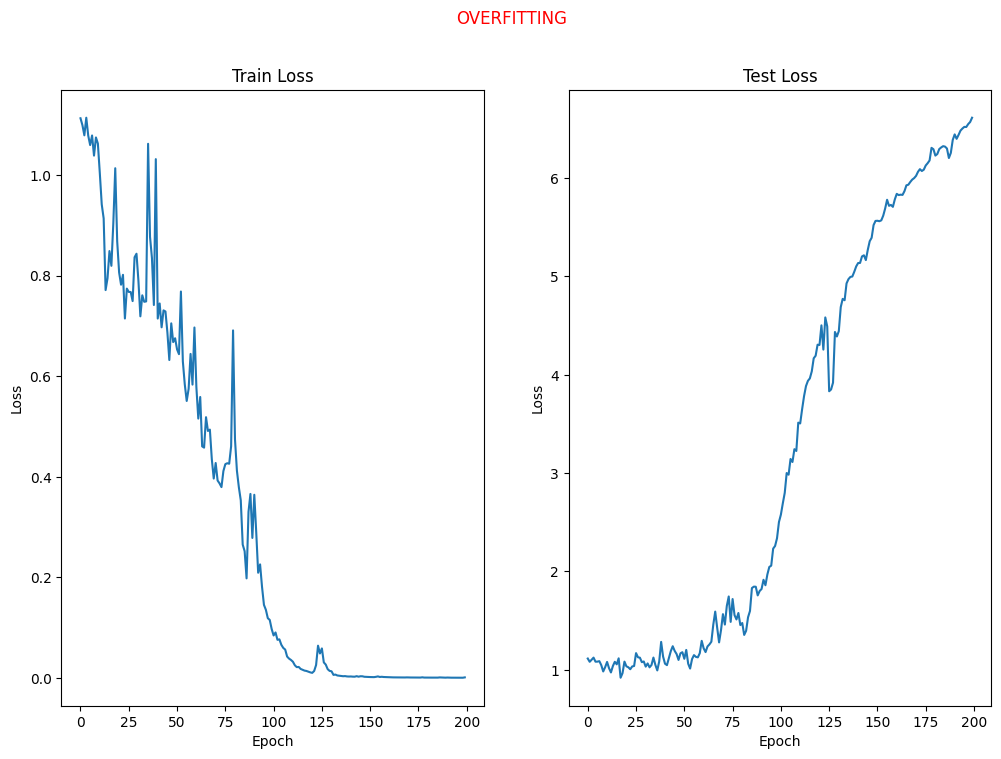

In [123]:
# plot the losses
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,8))
sets = ["Train", "Test"]
losses = [losses_train, losses_test]
for i, set_ in enumerate(sets):
    ax[i].plot(range(len(losses_train)), losses[i])
    ax[i].set_title(f"{set_} Loss")
    ax[i].set_xlabel("Epoch")
    ax[i].set_ylabel("Loss")       

_ = plt.suptitle("OVERFITTING", color="r")

Let's try to reduce overfitting by using data augmentation: this will in turn increases the sie of our dataset

In [138]:
train_transform_augmented = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor()
])

test_transform_augmented = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [139]:
train_dataset_augmented = datasets.ImageFolder(root=train_dir, transform=train_transform_augmented)
test_dataset_augmented = datasets.ImageFolder(root=test_dir, transform=test_transform_augmented)

In [140]:
train_loader_augmented = DataLoader(dataset=train_dataset_augmented, 
                                    batch_size=32, 
                                    shuffle=True, 
                                    num_workers=os.cpu_count()-4, 
                                    persistent_workers=True, 
                                    prefetch_factor=2)
test_loader_augmented = DataLoader(dataset=test_dataset_augmented, 
                                   batch_size=32,
                                   shuffle = False, 
                                   persistent_workers=True, 
                                   num_workers= os.cpu_count()-4,
                                   prefetch_factor=2)

In [141]:
model1 = TinyVGG(input_shape=3, hidden_units=10, output_shape=3).to(device)
optimizer = opt.Adam(lr=0.001, params=model1.parameters())
criterion = nn.CrossEntropyLoss()

In [142]:
# Training and testing loop
losses_train = []
losses_test = []
accuracy_train = []
accuracy_test = []
for epoch in range(epochs):
    model1.train()
    loss_train_acc = 0
    for X_batch_train, y_batch_train in train_loader_augmented:
        X_batch_train, y_batch_train = X_batch_train.to(device), y_batch_train.to(device)
        # make prediction
        preds_train = model1(X_batch_train)
        # compute the loss
        loss_train = criterion(preds_train, y_batch_train)
        loss_train_acc += loss_train.item()
        # zero the gradient
        optimizer.zero_grad()
        # perform back propagation
        loss_train.backward()
        # step the optimizer
        optimizer.step()
    losses_train.append(loss_train_acc/len(train_loader_augmented)) # normalize to have something comparable to the test dataset

    model1.eval()
    loss_test_acc = 0
    with torch.inference_mode():
        # make a prediction for the test set
        for X_batch_test, y_batch_test in test_loader_augmented:
            X_batch_test, y_batch_test = X_batch_test.to(device), y_batch_test.to(device)
            # make a prediction on the test set
            preds_test = model1(X_batch_test)
            # compute the loss
            loss_test = criterion(preds_test, y_batch_test)
            loss_test_acc += loss_test.item()
        losses_test.append(loss_test_acc/len(test_loader_augmented))
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}: | Loss Train: {losses_train[epoch]} | Loss Test: {losses_test[epoch]}")

Epoch: 0: | Loss Train: 1.1131304204463959 | Loss Test: 1.1101092100143433
Epoch: 10: | Loss Train: 0.8299127742648125 | Loss Test: 1.0143821835517883
Epoch: 20: | Loss Train: 0.7774128317832947 | Loss Test: 0.9856776793797811
Epoch: 30: | Loss Train: 0.7009489312767982 | Loss Test: 1.1355440815289815
Epoch: 40: | Loss Train: 0.8362351953983307 | Loss Test: 1.0361761053403218
Epoch: 50: | Loss Train: 0.6905617937445641 | Loss Test: 1.0391464829444885
Epoch: 60: | Loss Train: 0.8119902350008488 | Loss Test: 1.0251799821853638
Epoch: 70: | Loss Train: 0.660918153822422 | Loss Test: 1.0701156258583069
Epoch: 80: | Loss Train: 0.6110002063214779 | Loss Test: 1.1181612014770508
Epoch: 90: | Loss Train: 0.5100651476532221 | Loss Test: 1.1023316780726116
Epoch: 100: | Loss Train: 0.5299254693090916 | Loss Test: 1.1759442885716755
Epoch: 110: | Loss Train: 0.4014398716390133 | Loss Test: 1.3188410600026448
Epoch: 120: | Loss Train: 0.8058811575174332 | Loss Test: 1.3719726006189983
Epoch: 130:

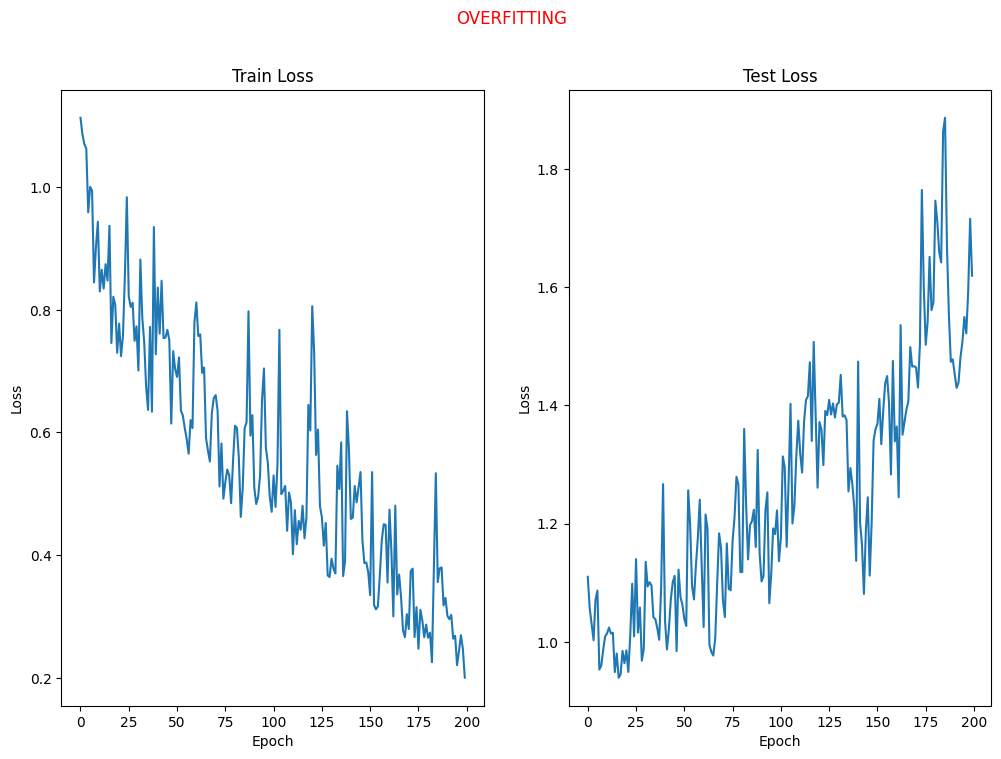

In [143]:
# plot the losses
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,8))
sets = ["Train", "Test"]
losses = [losses_train, losses_test]
for i, set_ in enumerate(sets):
    ax[i].plot(range(len(losses_train)), losses[i])
    ax[i].set_title(f"{set_} Loss")
    ax[i].set_xlabel("Epoch")
    ax[i].set_ylabel("Loss")       

_ = plt.suptitle("OVERFITTING", color="r")

Ok so we have tried to reduce overfitting using data augmentation

it does not deliver, we could try dropout or get more data, or also have bigger images (224x224 instead of the 64x64)

in fact the model is too complex for our dataset so overfitting in inevitable. 

Hence we could restore to transfer learning to use a model that was trained on more images and fine tune it to our problem